In [2]:
import re
import calendar

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Data Visualization and Exploratory Data Analysis Lab
## Visualizing and exploring data. The data mining process

In this lab, you'll get acquainted with the most streamed songs on Spotify in 2024. The dataset and its associated metadata can be found [here](https://www.kaggle.com/datasets/nelgiriyewithana/most-streamed-spotify-songs-2024). The version you'll need is provided in the `data/` folder.

You know the drill. Do what you can / want / need to answer the questions to the best of your ability. Answers do not need to be trivial, or even the same among different people.

### Problem 1. Read the dataset (1 point)
Read the file without unzipping it first. You can try a different character encoding, like `unicode_escape`. Don't worry too much about weird characters.

In [3]:
spotify_data = pd.read_csv("./data/spotify_most_streamed_2024.zip", encoding="unicode_escape")

In [4]:
spotify_data

,Track,Album Name,Artist,Release Date,ISRC,All Time Rank,Track Score,Spotify Streams,Spotify Playlist Count,Spotify Playlist Reach,...,SiriusXM Spins,Deezer Playlist Count,Deezer Playlist Reach,Amazon Playlist Count,Pandora Streams,Pandora Track Stations,Soundcloud Streams,Shazam Counts,TIDAL Popularity,Explicit Track
0,MILLION DOLLAR BABY,Million Dollar Baby - Single,Tommy Richman,4/26/2024,QM24S2402528,1,725.4,"390,470,936","30,716","196,631,588",...,684,62.0,"17,598,718",114.0,"18,004,655","22,931","4,818,457","2,669,262",NaN,0
1,Not Like Us,Not Like Us,Kendrick Lamar,5/4/2024,USUG12400910,2,545.9,"323,703,884","28,113","174,597,137",...,3,67.0,"10,422,430",111.0,"7,780,028","28,444","6,623,075","1,118,279",NaN,1
2,i like the way you kiss me,I like the way you kiss me,Artemas,3/19/2024,QZJ842400387,3,538.4,"601,309,283","54,331","211,607,669",...,536,136.0,"36,321,847",172.0,"5,022,621","5,639","7,208,651","5,285,340",NaN,0
3,Flowers,Flowers - Single,Miley Cyrus,1/12/2023,USSM12209777,4,444.9,"2,031,280,633","269,802","136,569,078",...,"2,182",264.0,"24,684,248",210.0,"190,260,277","203,384",NaN,"11,822,942",NaN,0
4,Houdini,Houdini,Eminem,5/31/2024,USUG12403398,5,423.3,"107,034,922","7,223","151,469,874",...,1,82.0,"17,660,624",105.0,"4,493,884","7,006","207,179","457,017",NaN,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4595,For the Last Time,For the Last Time,$uicideboy$,9/5/2017,QM8DG1703420,"4,585",19.4,"305,049,963","65,770","5,103,054",...,NaN,2.0,"14,217",NaN,"20,104,066","13,184","50,633,006","656,337",NaN,1
4596,Dil Meri Na Sune,"Dil Meri Na Sune (From ""Genius"")",Atif Aslam,7/27/2018,INT101800122,"4,575",19.4,"52,282,360","4,602","1,449,767",...,NaN,1.0,927,NaN,NaN,NaN,NaN,"193,590",NaN,0
4597,Grace (feat. 42 Dugg),My Turn,Lil Baby,2/28/2020,USUG12000043,"4,571",19.4,"189,972,685","72,066","6,704,802",...,NaN,1.0,74,6.0,"84,426,740","28,999",NaN,"1,135,998",NaN,1
4598,Nashe Si Chadh Gayi,November Top 10 Songs,Arijit Singh,11/8/2016,INY091600067,"4,591",19.4,"145,467,020","14,037","7,387,064",...,NaN,NaN,NaN,7.0,"6,817,840",NaN,NaN,"448,292",NaN,0


### Problem 2. Perform some cleaning (1 point)
Ensure all data has been read correctly; check the data types. Give the columns better names (e.g. `all_time_rank`, `track_score`, etc.). To do so, try to use `apply()` instead of a manual mapping between old and new name. Get rid of any unnecessary ones.

In [5]:
def to_snake_case(col_name):
    col_name = col_name.strip()
    col_name = col_name.lower()
    col_name = re.sub(r"[^\w\s]", "_", col_name) # replace non-alphanumeric characters with underscores
    col_name = re.sub(r"\s+", "_", col_name) # regex is used instead of replace to handle multiple spaces
    col_name = re.sub(r"_+", "_", col_name)  # replace multiple underscores with a single underscore
    col_name = col_name.rstrip("_")

    return col_name

In [6]:
spotify_data.columns = spotify_data.columns.to_series().apply(to_snake_case)

In [7]:
spotify_data.columns

Index(['track', 'album_name', 'artist', 'release_date', 'isrc',
       'all_time_rank', 'track_score', 'spotify_streams',
       'spotify_playlist_count', 'spotify_playlist_reach',
       'spotify_popularity', 'youtube_views', 'youtube_likes', 'tiktok_posts',
       'tiktok_likes', 'tiktok_views', 'youtube_playlist_reach',
       'apple_music_playlist_count', 'airplay_spins', 'siriusxm_spins',
       'deezer_playlist_count', 'deezer_playlist_reach',
       'amazon_playlist_count', 'pandora_streams', 'pandora_track_stations',
       'soundcloud_streams', 'shazam_counts', 'tidal_popularity',
       'explicit_track'],
      dtype='object')

In [8]:
spotify_data.isrc.count() == spotify_data.shape[0]

np.True_

In [9]:
spotify_data = spotify_data.drop(columns=["isrc"])

In [10]:
spotify_data.dtypes.reset_index().rename(columns={"index": "feature", 0: "data_type"})

,feature,data_type
0,track,object
1,album_name,object
2,artist,object
3,release_date,object
4,all_time_rank,object
5,track_score,float64
6,spotify_streams,object
7,spotify_playlist_count,object
8,spotify_playlist_reach,object
9,spotify_popularity,float64


In [11]:
object_to_float_cols = [
    "all_time_rank",
    "spotify_streams",
    "spotify_playlist_count",
    "spotify_playlist_reach",
    "youtube_views",
    "youtube_likes",
    "tiktok_posts",
    "tiktok_likes",
    "tiktok_views",
    "youtube_playlist_reach",
    "airplay_spins",
    "siriusxm_spins",
    "deezer_playlist_reach",
    "pandora_streams",
    "pandora_track_stations",
    "soundcloud_streams",
    "shazam_counts"]

In [12]:
spotify_data[object_to_float_cols]

,all_time_rank,spotify_streams,spotify_playlist_count,spotify_playlist_reach,youtube_views,youtube_likes,tiktok_posts,tiktok_likes,tiktok_views,youtube_playlist_reach,airplay_spins,siriusxm_spins,deezer_playlist_reach,pandora_streams,pandora_track_stations,soundcloud_streams,shazam_counts
0,1,"390,470,936","30,716","196,631,588","84,274,754","1,713,126","5,767,700","651,565,900","5,332,281,936","150,597,040","40,975",684,"17,598,718","18,004,655","22,931","4,818,457","2,669,262"
1,2,"323,703,884","28,113","174,597,137","116,347,040","3,486,739","674,700","35,223,547","208,339,025","156,380,351","40,778",3,"10,422,430","7,780,028","28,444","6,623,075","1,118,279"
2,3,"601,309,283","54,331","211,607,669","122,599,116","2,228,730","3,025,400","275,154,237","3,369,120,610","373,784,955","74,333",536,"36,321,847","5,022,621","5,639","7,208,651","5,285,340"
3,4,"2,031,280,633","269,802","136,569,078","1,096,100,899","10,629,796","7,189,811","1,078,757,968","14,603,725,994","3,351,188,582","1,474,799","2,182","24,684,248","190,260,277","203,384",NaN,"11,822,942"
4,5,"107,034,922","7,223","151,469,874","77,373,957","3,670,188","16,400",NaN,NaN,"112,763,851","12,185",1,"17,660,624","4,493,884","7,006","207,179","457,017"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4595,"4,585","305,049,963","65,770","5,103,054","149,247,747","1,397,590","48,370","20,202,000","143,934,379","53,016",6,NaN,"14,217","20,104,066","13,184","50,633,006","656,337"
4596,"4,575","52,282,360","4,602","1,449,767","943,920,245","5,347,766",NaN,"1,721","19,935","24,973,048",412,NaN,927,NaN,NaN,NaN,"193,590"
4597,"4,571","189,972,685","72,066","6,704,802","201,027,333","1,081,402","7,596","5,288,677","36,849,005","29,253,152",204,NaN,74,"84,426,740","28,999",NaN,"1,135,998"
4598,"4,591","145,467,020","14,037","7,387,064","1,118,595,159","3,868,828","11,433","2,534,831","37,757,301","25,150,516","1,200",NaN,NaN,"6,817,840",NaN,NaN,"448,292"


In [13]:
def clean_numeric_with_commas(value):
    value = str(value)
    value = value.replace(",", "")
    
    return pd.to_numeric(value, errors="coerce")

In [14]:
spotify_data[object_to_float_cols] = spotify_data[object_to_float_cols].apply(
    lambda col: col.apply(clean_numeric_with_commas)
)

In [15]:
spotify_data.release_date = pd.to_datetime(spotify_data.release_date, errors="coerce")

In [16]:
spotify_data

,track,album_name,artist,release_date,all_time_rank,track_score,spotify_streams,spotify_playlist_count,spotify_playlist_reach,spotify_popularity,...,siriusxm_spins,deezer_playlist_count,deezer_playlist_reach,amazon_playlist_count,pandora_streams,pandora_track_stations,soundcloud_streams,shazam_counts,tidal_popularity,explicit_track
0,MILLION DOLLAR BABY,Million Dollar Baby - Single,Tommy Richman,2024-04-26,1,725.4,3.904709e+08,30716.0,196631588.0,92.0,...,684.0,62.0,17598718.0,114.0,18004655.0,22931.0,4818457.0,2669262.0,NaN,0
1,Not Like Us,Not Like Us,Kendrick Lamar,2024-05-04,2,545.9,3.237039e+08,28113.0,174597137.0,92.0,...,3.0,67.0,10422430.0,111.0,7780028.0,28444.0,6623075.0,1118279.0,NaN,1
2,i like the way you kiss me,I like the way you kiss me,Artemas,2024-03-19,3,538.4,6.013093e+08,54331.0,211607669.0,92.0,...,536.0,136.0,36321847.0,172.0,5022621.0,5639.0,7208651.0,5285340.0,NaN,0
3,Flowers,Flowers - Single,Miley Cyrus,2023-01-12,4,444.9,2.031281e+09,269802.0,136569078.0,85.0,...,2182.0,264.0,24684248.0,210.0,190260277.0,203384.0,NaN,11822942.0,NaN,0
4,Houdini,Houdini,Eminem,2024-05-31,5,423.3,1.070349e+08,7223.0,151469874.0,88.0,...,1.0,82.0,17660624.0,105.0,4493884.0,7006.0,207179.0,457017.0,NaN,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4595,For the Last Time,For the Last Time,$uicideboy$,2017-09-05,4585,19.4,3.050500e+08,65770.0,5103054.0,71.0,...,NaN,2.0,14217.0,NaN,20104066.0,13184.0,50633006.0,656337.0,NaN,1
4596,Dil Meri Na Sune,"Dil Meri Na Sune (From ""Genius"")",Atif Aslam,2018-07-27,4575,19.4,5.228236e+07,4602.0,1449767.0,56.0,...,NaN,1.0,927.0,NaN,NaN,NaN,NaN,193590.0,NaN,0
4597,Grace (feat. 42 Dugg),My Turn,Lil Baby,2020-02-28,4571,19.4,1.899727e+08,72066.0,6704802.0,65.0,...,NaN,1.0,74.0,6.0,84426740.0,28999.0,NaN,1135998.0,NaN,1
4598,Nashe Si Chadh Gayi,November Top 10 Songs,Arijit Singh,2016-11-08,4591,19.4,1.454670e+08,14037.0,7387064.0,66.0,...,NaN,NaN,NaN,7.0,6817840.0,NaN,NaN,448292.0,NaN,0


### Problem 3. Most productive artists (1 point)
Who are the five artists with the most songs in the dataset?

Who are the five "clean-mouthed" artists (i.e., with no explicit songs)? **Note:** We're not going into details but we can start a discussion about whether a song needs swearing to be popular.

In [17]:
artists_song_count = (spotify_data
                      .groupby("artist").track
                      .count()
                      .reset_index(name="song_count")
                      .sort_values(by="song_count", ascending=False)
                      .head(5))

In [18]:
artists_song_count

,artist,song_count
1690,Taylor Swift,63
517,Drake,63
183,Bad Bunny,60
915,KAROL G,32
1728,The Weeknd,31


As we can see, the first and the second artists have equal songs count and therefore we cannot exactly see the top 5. This is why we need to use a different approach.

In [19]:
def get_top_artists(data, top_n=5, group_by="artist", agg_column="track", agg_func="count"):
    # Create descriptive column name for aggregated values
    agg_col_name = f"{agg_func}_{agg_column}"

    # Group by specified column and apply aggregation function
    grouped = data.groupby(group_by)[agg_column].agg(agg_func)
    
    # Reset index and sort by aggregated values in descending order
    result = (grouped.reset_index(name=agg_col_name)
              .sort_values(by=agg_col_name, ascending=False))
    
    # Assign rank to each group based on aggregated values, with ties getting the same rank and the next rank being the next integer (dense ranking)
    result["rank"] = result[agg_col_name].rank(method="dense", ascending=False)
    
    # Filter groups to get only those with rank <= top_n, and drop the rank column
    return result[result["rank"] <= top_n].drop(columns=["rank"])

In [20]:
artists_top5 = get_top_artists(spotify_data, top_n=5)
artists_top5

,artist,count_track
1690,Taylor Swift,63
517,Drake,63
183,Bad Bunny,60
915,KAROL G,32
1728,The Weeknd,31
1763,Travis Scott,30


Now let's see if there are other than 0 and 1 values for *explicit_track*

In [21]:
spotify_data.explicit_track.value_counts()

explicit_track
0    2949
1    1651
Name: count, dtype: int64

There are several methods to check whether an artist has any explicit songs. We use the `groupby()` method with different aggregation functions like `sum()`, `any()`, and `max()`. Since `any()` is the fastest (uses short-circuit evaluation) and most semantically correct (directly answers "does this artist have any explicit songs?"), we use it in our solution.

In [22]:
# get all artists that have no explicit tracks in the dataset
artist_has_explicit = spotify_data.groupby("artist").explicit_track.any()
clean_artists = artist_has_explicit[~artist_has_explicit].index
no_explicit_artists = spotify_data[spotify_data.artist.isin(clean_artists)]

print(f"Number of artists with no explicit tracks: {no_explicit_artists.shape[0]}")

Number of artists with no explicit tracks: 2119


In [23]:
artists_top5_not_explicit = get_top_artists(no_explicit_artists, top_n=5)
artists_top5_not_explicit

,artist,count_track
519,Imagine Dragons,16
116,BTS,14
734,Luke Combs,13
702,Linkin Park,13
178,Bruno Mars,12
488,Harry Styles,12
904,Ozuna,12
1057,Sia,12
865,NewJeans,11
1047,Shawn Mendes,11


### Problem 4. Most streamed artists (1 point)
And who are the top five most streamed (as measured by Spotify streams) artists?

In [24]:
spotify_data.spotify_streams.dtype

dtype('float64')

In [25]:
most_streamed_tracks = get_top_artists(spotify_data, top_n=5, agg_column="spotify_streams", agg_func="sum")
most_streamed_tracks

,artist,sum_spotify_streams
183,Bad Bunny,3.705483e+10
1728,The Weeknd,3.694854e+10
517,Drake,3.496216e+10
1690,Taylor Swift,3.447077e+10
1428,Post Malone,2.613747e+10


### Problem 5. Songs by year and month (1 point)
How many songs have been released each year? Present an appropriate plot. Can you explain the behavior of the plot for 2024?

How about months? Is / Are there (a) popular month(s) to release music?

In [26]:
spotify_data.release_date.dtype

dtype('<M8[ns]')

In [27]:
# Count songs by year
songs_by_year = (spotify_data.groupby(spotify_data.release_date.dt.year).track
                 .count()
                 .reset_index(name="song_count"))

songs_by_year.columns = ["year", "song_count"]

In [28]:
def plot_songs_by_period(data, period_col, col_names=None):
    period_label = period_col.capitalize()
    
    plt.figure(figsize=(12, 8))
    
    # Use sequential positions to avoid gaps
    x_positions = range(len(data))
    bars = plt.bar(x_positions, data.song_count)
    
    # Add count labels on top of the bars
    plt.bar_label(bars, fmt='%d', padding=3, fontsize=10)
    
    plt.xlabel(period_label, fontsize=12)
    plt.ylabel("Number of Songs", fontsize=12)
    plt.title(f"Number of Songs Released Per {period_label}", fontsize=16, fontweight="bold")
    
    # Set x-axis labels to actual period values
    labels = col_names if col_names is not None else data[period_col].astype(str)
    plt.xticks(x_positions, labels, rotation=45)
    
    plt.tight_layout()
    plt.show()

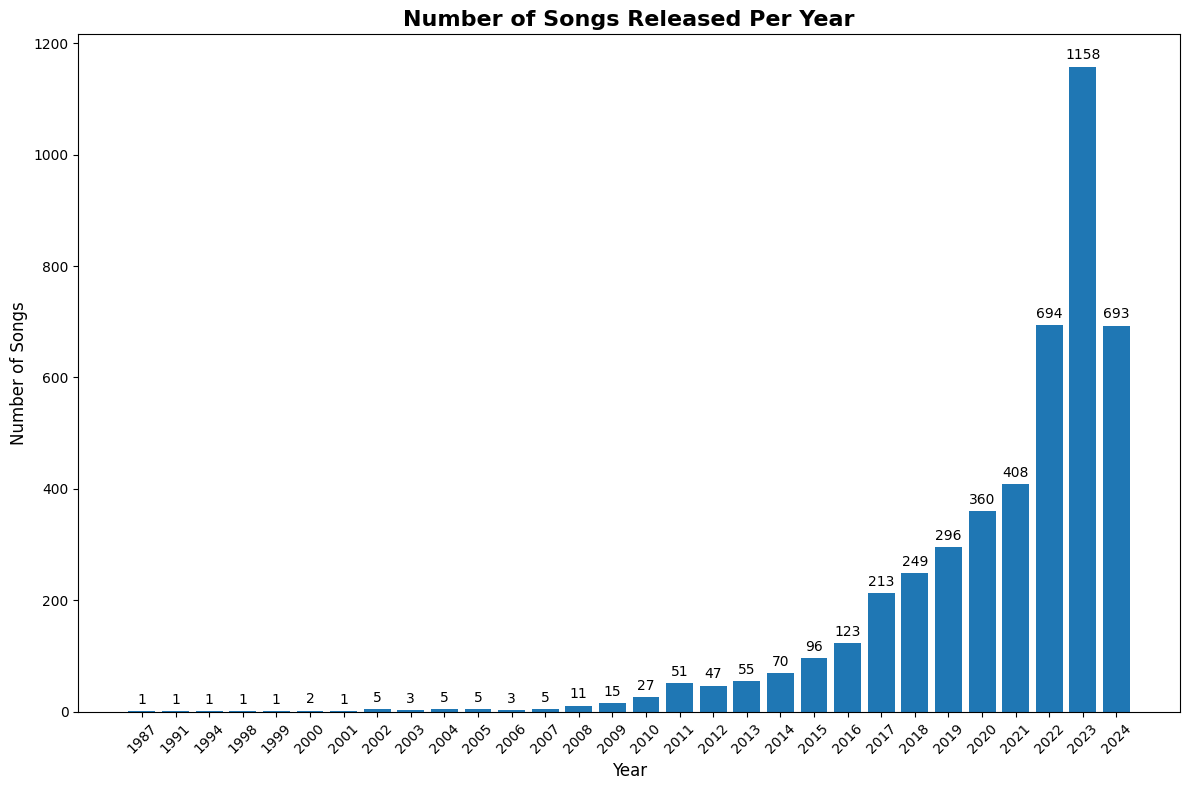

In [29]:
plot_songs_by_period(songs_by_year, "year")

The lower number of songs in 2024 is expected because the dataset is collected during the same year, meaning only a partial year of releases is included.

In [30]:
spotify_data.release_date.dt.month

0        4
1        5
2        3
3        1
4        5
        ..
4595     9
4596     7
4597     2
4598    11
4599     4
Name: release_date, Length: 4600, dtype: int32

In [31]:
songs_by_month = (spotify_data.groupby(spotify_data.release_date.dt.month).track
                 .count()
                 .reset_index(name="song_count"))

songs_by_month.columns = ["month", "song_count"]

In [32]:
col_names = songs_by_month.month.apply(lambda m: calendar.month_name[m])

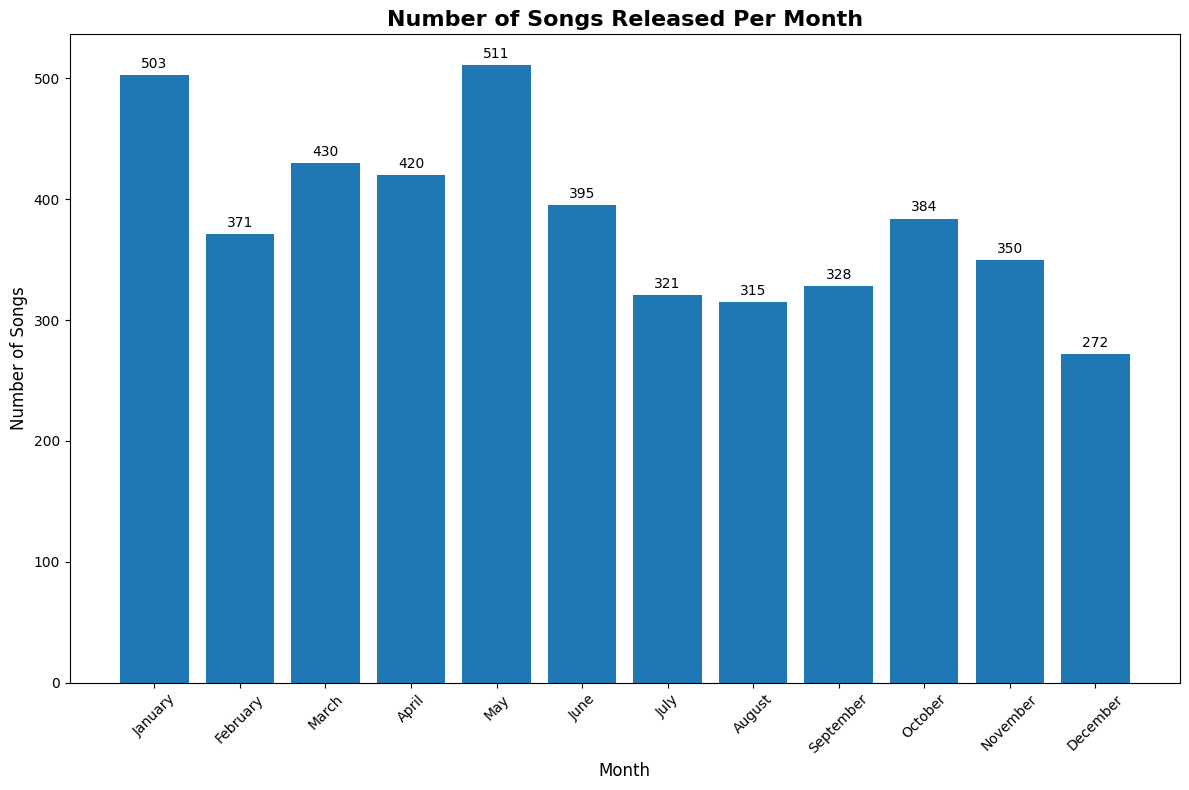

In [33]:
plot_songs_by_period(songs_by_month, "month", col_names)

The two months with the most song releases are **January** and **May**, while **December** has the fewest releases. This pattern can be explained by several factors:

- **December's low activity:** Artists avoid releasing during the holiday season due to reduced listening engagement and saturation with holiday-themed music.

- **May's peak:** The pre-summer timing allows songs to accumulate popularity before the high-activity summer streaming period.

- **January's popularity:** The new year brings renewed activity on streaming platforms, and artists capitalize on fresh listener engagement after the holiday break. Additionally, some releases may include new year-themed content.

This distribution aligns with strategic release planning in the music industry, where timing is crucial for maximizing chart performance and streaming numbers.

### Problem 6. Playlists (2 points)
Is there any connection (correlation) between users adding a song to playlists in one service, or another? Only Spotify, Apple, Deezer, and Amazon offer the ability to add a song to a playlist. Find a way to plot all these relationships at the same time, and analyze them. Experiment with different types of correlations.

In [34]:
spotify_data.columns

Index(['track', 'album_name', 'artist', 'release_date', 'all_time_rank',
       'track_score', 'spotify_streams', 'spotify_playlist_count',
       'spotify_playlist_reach', 'spotify_popularity', 'youtube_views',
       'youtube_likes', 'tiktok_posts', 'tiktok_likes', 'tiktok_views',
       'youtube_playlist_reach', 'apple_music_playlist_count', 'airplay_spins',
       'siriusxm_spins', 'deezer_playlist_count', 'deezer_playlist_reach',
       'amazon_playlist_count', 'pandora_streams', 'pandora_track_stations',
       'soundcloud_streams', 'shazam_counts', 'tidal_popularity',
       'explicit_track'],
      dtype='object')

In [35]:
playlist_columns = ["spotify_playlist_count", "apple_music_playlist_count",
                    "deezer_playlist_count", "amazon_playlist_count"]

In [36]:
# Select relevant columns
playlist_data = spotify_data[playlist_columns].copy()

In [37]:
# Rename for cleaner labels
playlist_data.columns = ["Spotify", "Apple Music", "Deezer", "Amazon"]

In [38]:
playlist_data

,Spotify,Apple Music,Deezer,Amazon
0,30716.0,210.0,62.0,114.0
1,28113.0,188.0,67.0,111.0
2,54331.0,190.0,136.0,172.0
3,269802.0,394.0,264.0,210.0
4,7223.0,182.0,82.0,105.0
...,...,...,...,...
4595,65770.0,3.0,2.0,NaN
4596,4602.0,1.0,1.0,NaN
4597,72066.0,19.0,1.0,6.0
4598,14037.0,1.0,NaN,7.0


In [39]:
def plot_distributions(data, cols, n_cols=2, figsize=None):
    n_plots = len(cols)
    n_rows = (n_plots + n_cols - 1) // n_cols
    
    if figsize is None:
        figsize = (7 * n_cols, 5 * n_rows)
    
    _, axes = plt.subplots(n_rows, n_cols, figsize=figsize, squeeze=False)
    axes = axes.flatten()
    
    for ax, col in zip(axes, cols):
        ax.hist(data[col].dropna(), bins="fd", edgecolor="black")
        ax.set_title(f"{col} Distribution", fontweight="bold")
        ax.set_xlabel("Count")
        ax.set_ylabel("Frequency")
    
    # Hide extra subplots
    for ax in axes[n_plots:]:
        ax.axis("off")
    
    plt.tight_layout()
    plt.show()

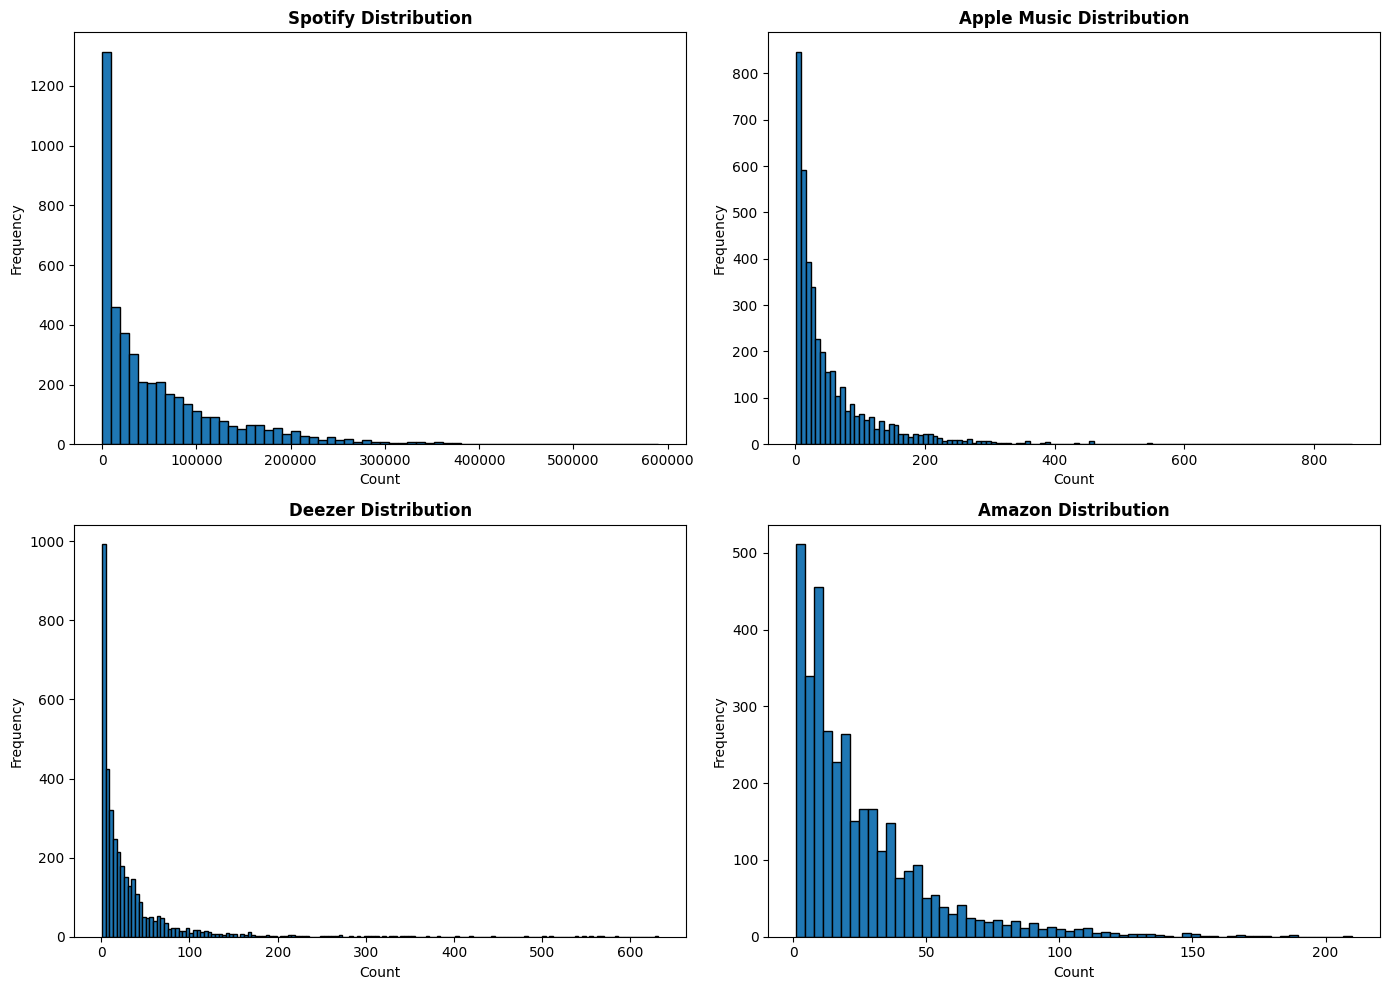

In [40]:
# Visualize distributions
plot_distributions(playlist_data, playlist_data.columns)

In [41]:
def print_skewness(data, cols):
    for col in cols:
        skewness = data[col].skew()
        print(f"{col}: {skewness:.2f}")

In [42]:
print_skewness(playlist_data, playlist_data.columns)

Spotify: 1.84
Apple Music: 2.89
Deezer: 4.79
Amazon: 2.19


The distributions are **highly right-skewed** (skewness values: 1.84, 2.89, 4.79, 2.19), with most songs in few playlists and rare viral hits in thousands. This makes **Spearman correlation** appropriate, as it handles skewed data and outliers better than Pearson.

In [43]:
# Calculate correlation matrix
correlation_matrix = playlist_data.corr(method="spearman")

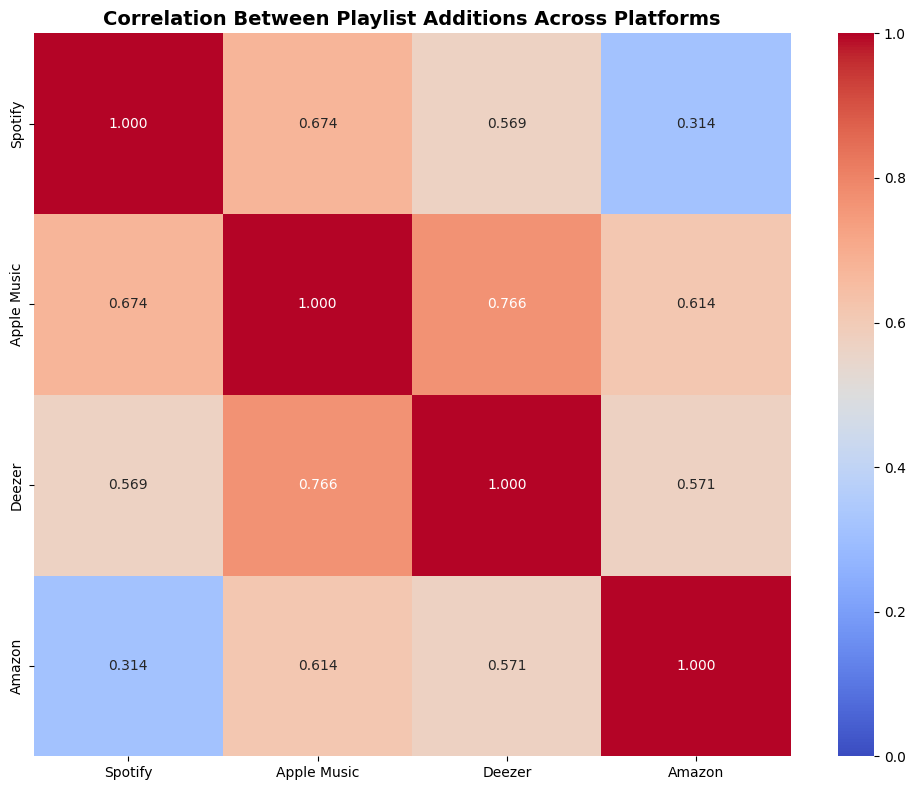

In [44]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".3f",
    vmin=0,
    vmax=1,
    cmap="coolwarm")

plt.title(
    "Correlation Between Playlist Additions Across Platforms", 
    fontsize=14,
    fontweight="bold")

plt.tight_layout()
plt.show()

In [45]:
# Extract upper triangle (unique correlations, excluding diagonal)
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool), k=1)
correlations = correlation_matrix.where(mask).stack()

In [46]:
print(f"Average cross-platform correlation: {correlations.mean():.3f}")
print(f"Standard deviation: {correlations.std():.3f}")
print(f"Strongest correlation: {correlations.idxmax()} = {correlations.max():.3f}")
print(f"Weakest correlation: {correlations.idxmin()} = {correlations.min():.3f}")

Average cross-platform correlation: 0.585
Standard deviation: 0.152
Strongest correlation: ('Apple Music', 'Deezer') = 0.766
Weakest correlation: ('Spotify', 'Amazon') = 0.314


This indicates that while hits generally perform well across platforms, there are notable platform-specific differences.

In [47]:
def plot_correlation_extremes(
        data,
        pair,
        corr_val,
        corr_type="strongest",
        figsize=(8, 6),
        color="steelblue"):
    col1, col2 = pair
    
    plt.figure(figsize=figsize)
    plt.scatter(data[col1], data[col2], alpha=0.4, s=30, color=color)
    plt.xlabel(f"{col1.replace('_', ' ').title()}", fontsize=11)
    plt.ylabel(f"{col2.replace('_', ' ').title()}", fontsize=11)
    
    title = f"{corr_type.capitalize()} Correlation: "
    title += rf"{col1.replace('_playlist_count', '').replace('_', ' ').title()} $\leftrightarrow$ "
    title += f"{col2.replace('_playlist_count', '').replace('_', ' ').title()}\n"
    title += rf"(Spearman $\rho$ = {corr_val:.3f})"
    
    plt.title(title, fontweight="bold")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [48]:
strongest_pair = correlations.idxmax()
strongest_val = correlations.max()
weakest_pair = correlations.idxmin()
weakest_val = correlations.min()

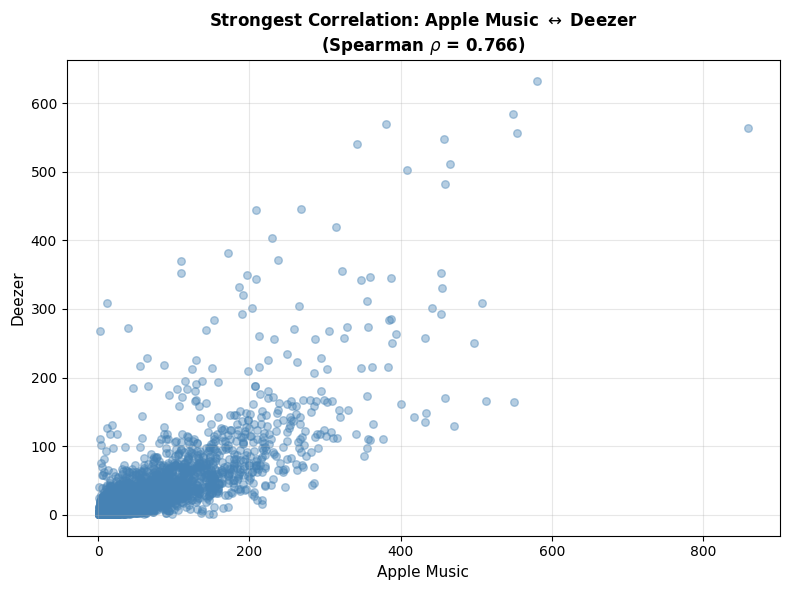

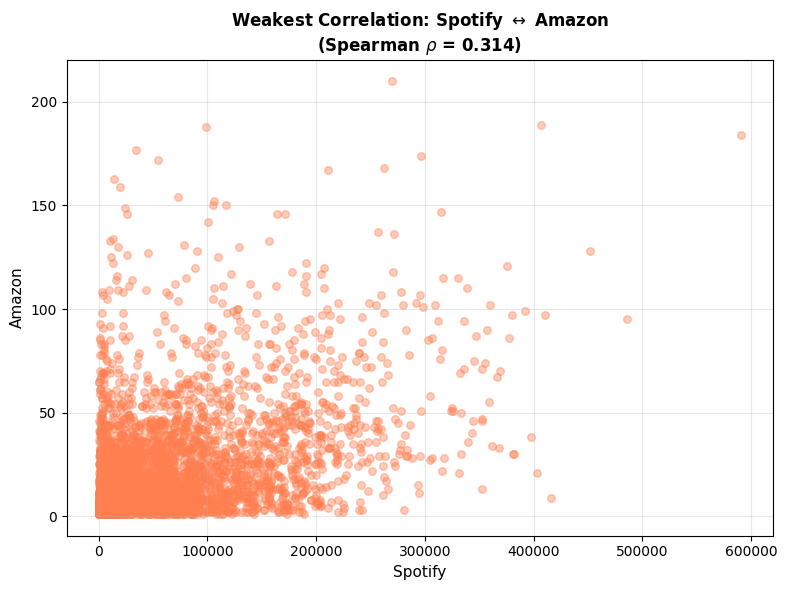

In [49]:
plot_correlation_extremes(
    playlist_data, 
    strongest_pair,
    corr_val=correlations.max(),
    corr_type="strongest",
    color="steelblue"
)

plot_correlation_extremes(
    playlist_data,
    weakest_pair,
    corr_val=correlations.min(),
    corr_type="weakest",
    color="coral"
)

The scatter plots illustrate these extremes: Apple Music $\leftrightarrow$ Deezer shows tight clustering (strong correlation), while Spotify $\leftrightarrow$ Amazon shows dispersion (weak correlation), confirming Amazon's distinct playlist ecosystem.

### Problem 7. YouTube views and likes (1 point)
What is the relationship between YouTube views and likes? Present an appropriate plot. 

What is the mean YouTube views-to-likes ratio? What is its distribution? Find a way to plot it and describe it.

In [50]:
youtube_data = spotify_data[["youtube_views", "youtube_likes"]]

In [51]:
youtube_data

,youtube_views,youtube_likes
0,8.427475e+07,1713126.0
1,1.163470e+08,3486739.0
2,1.225991e+08,2228730.0
3,1.096101e+09,10629796.0
4,7.737396e+07,3670188.0
...,...,...
4595,1.492477e+08,1397590.0
4596,9.439202e+08,5347766.0
4597,2.010273e+08,1081402.0
4598,1.118595e+09,3868828.0


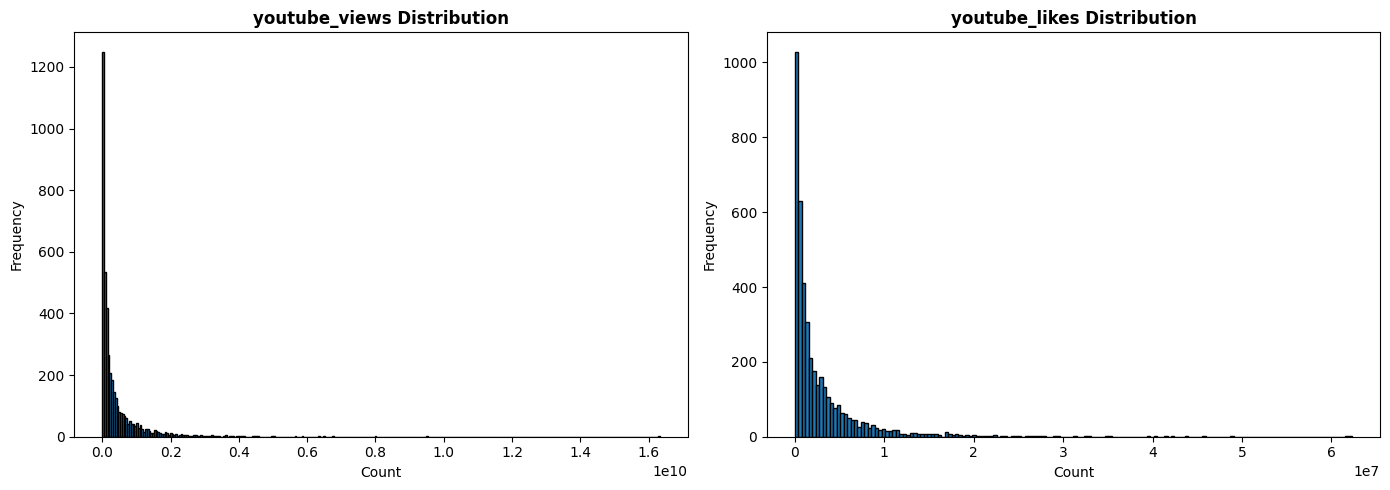

In [52]:
plot_distributions(spotify_data, youtube_data.columns)

In [53]:
print_skewness(youtube_data, youtube_data.columns)

youtube_views: 6.02
youtube_likes: 4.22


The distributions are **highly right-skewed** (youtube_views: 6.02, youtube_likes: 4.22), with most songs having few views/likes and a small number of viral hits reaching billions of views. This makes **Spearman correlation** the appropriate choice.

In [54]:
corr_val = youtube_data.youtube_views.corr(youtube_data.youtube_likes, method="spearman")
print(f"Spearman correlation: {corr_val:.3f}")

Spearman correlation: 0.931


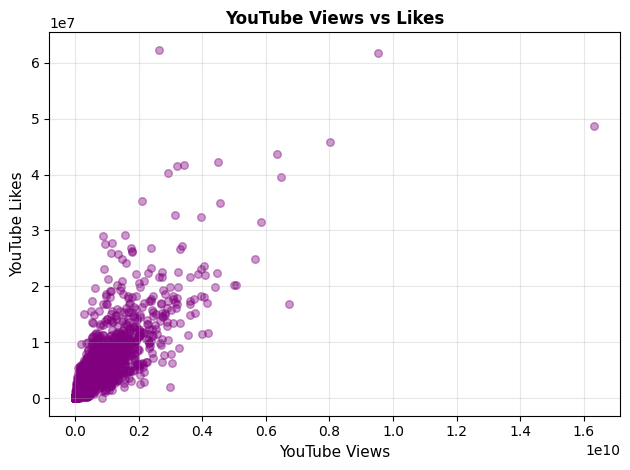

In [55]:
plt.scatter(youtube_data.youtube_views, youtube_data.youtube_likes, alpha=0.4, s=30, color="purple")
plt.xlabel("YouTube Views", fontsize=11)
plt.ylabel("YouTube Likes", fontsize=11)
plt.title("YouTube Views vs Likes", fontweight="bold")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The scatter plot confirms a strong positive correlation, but the extreme scale of music hits where a few viral songs reach billions of views compresses the majority of the dataset into the lower-left corner. This visualization makes it difficult to assess the relationship for the vast majority of songs with lower reach. To reveal the underlying patterns across the entire spectrum of popularity, a logarithmic transformation is necessary.

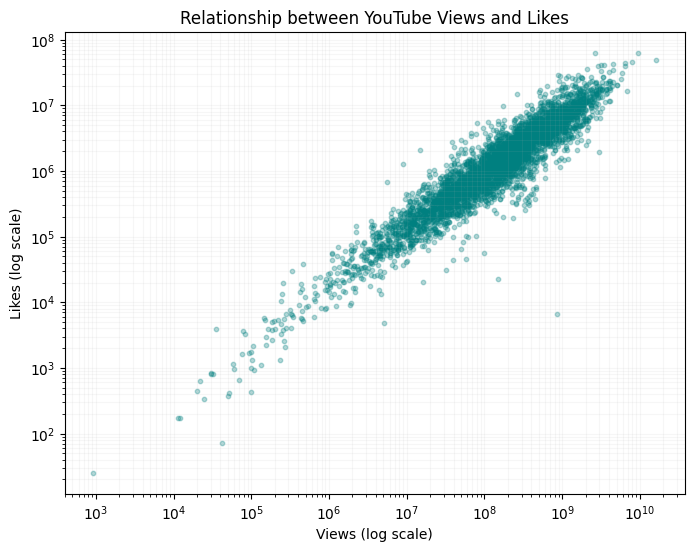

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(youtube_data.youtube_views, youtube_data.youtube_likes, alpha=0.3, s=10, color='teal')

plt.xscale("log")
plt.yscale("log")

plt.title("Relationship between YouTube Views and Likes")
plt.xlabel("Views (log scale)")
plt.ylabel("Likes (log scale)")
plt.grid(True, which="both", ls="-", alpha=0.1)
plt.show()

The log visualization reveals that the relationship between views and likes remains consistent across all levels of popularity, from niche tracks to global hits. The high Spearman correlation ($\rho = 0.931$) suggests that engagement scales predictably. However, the 'spread' around the main trend line likely accounts for the different ways fans consume music: some tracks may have high replay value (increasing views but not likes), while others spark immediate engagement.

In [56]:
# Mean ratio
ratio = youtube_data.youtube_views / youtube_data.youtube_likes
mean_ratio = ratio.mean()

print(f"Mean views-to-likes ratio: {mean_ratio:.2f}")

Mean views-to-likes ratio: 169.12


In [57]:
ratio.describe()

count      4285.000000
mean        169.116113
std        1978.564598
min           6.929676
25%          75.524433
50%         111.001674
75%         167.772855
max      129287.789776
dtype: float64

In [85]:
# Filter the data (take 99th percentile as cutoff)
q99 = ratio.quantile(0.99)
filtered_data = ratio[ratio <= q99].dropna()

In [86]:
# Calculate metrics on the filtered set
mean_val = filtered_data.mean()
std_val = filtered_data.std()

In [87]:
def plot_ratio_distribution(ratio_data, mean_val, std_val):
    plt.figure(figsize=(10, 6))
    plt.hist(ratio_data, bins="fd", edgecolor="black", color="teal", alpha=0.8)

    plt.axvline(mean_val, color="red", linestyle="--", label=f"Mean: {mean_val:.2f}")
    plt.axvline(mean_val - std_val, color="blue", linestyle=":", label=f"STD Range: {mean_val-std_val:.2f} - {mean_val+std_val:.2f}")
    plt.axvline(mean_val + std_val, color="blue", linestyle=":")

    plt.title("Distribution of Views-to-Likes Ratio (Capped at 99th Percentile)")
    plt.xlabel("Views-to-Likes Ratio")
    plt.ylabel("Frequency")

    plt.legend()

    plt.show()

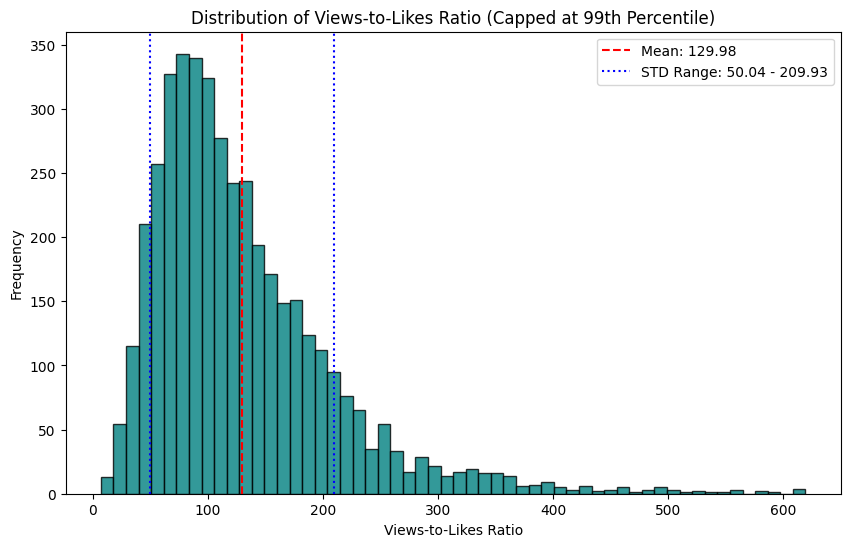

In [88]:
plot_ratio_distribution(filtered_data, mean_val, std_val)

The views-to-likes ratio is heavily right-skewed. By capping the data at the 99th percentile, we exclude extreme outliers that distort the scale, revealing that most songs fall between a 50 and 200 ratio.

In [95]:
def plot_views_likes_boxplot(ratio):
    ratio = ratio.dropna()
    ratio = ratio[ratio > 0]

    plt.figure(figsize=(10, 3))
    ax = plt.gca()

    ax.boxplot(ratio, vert=False, showfliers=True)

    ax.set_xscale("log")
    ax.set_title("Boxplot of Views-to-Likes Ratio")
    ax.set_xlabel("Views-to-Likes Ratio (log scale)")

    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

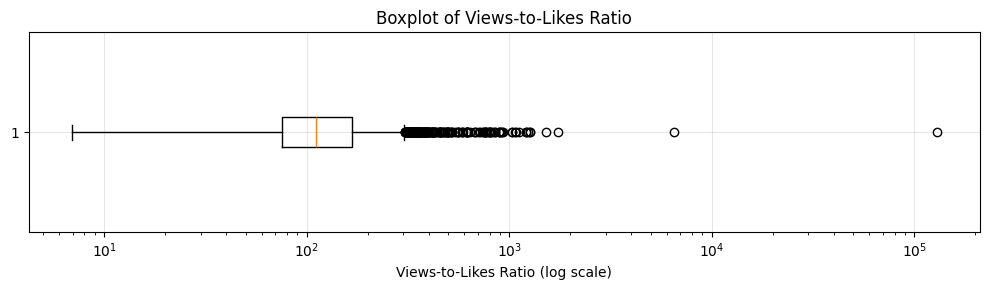

In [61]:
plot_views_likes_boxplot(ratio)

The boxplot highlights a "heavy tail" where the median (111.0) is much lower than the mean (169.1), indicating that while typical engagement is high, a few songs either require an enormous number of views to generate a single like or people are listening to them more than once or twice.

### Problem 8. TikTok stuff (2 points)
The most popular songs on TikTok released every year show... interesting behavior. Which years peaked the most TikTok views? Show an appropriate chart. Can you explain this behavior? For a bit of context, TikTok was created in 2016.

Now, how much popular is the most popular song for each release year, than the mean popularity? Analyze the results.

In both parts, it would be helpful to see the actual songs.

### * Problem 9. Explore (and clean) at will
There is a lot to look for here. For example, you can easily link a song to its genres, and lyrics. You may also try to link artists and albums to more info about them. Or you can compare and contrast a song's performance across different platforms, in a similar manner to what you already did above; maybe even assign a better song ranking system (across platforms with different popularity metrics, and different requirements) than the one provided in the dataset.